# SIVE — Sotto-esperimento C3-noise: caratterizzazione del rumore strumentale

Sotto-esperimento separato dalla campagna principale (`sive_harness.ipynb`),
pensato per isolare il rumore intrinseco dello strumento dalla variabilità
interpersonale. Tre agenti fissi (uno per gruppo LOW/MED/HIGH) ricevono
`N_REPS` repliche indipendenti e identiche dello stimolo MSG_POS, alla
stessa temperatura; la deviazione standard del delta PRE/POST tra repliche
identiche, a parità di persona, isola il rumore di campionamento del
modello da ogni differenza dovuta al profilo dell'agente.

**Prerequisiti**: eseguire prima le celle 1-9 di `sive_harness.ipynb`
nella stessa sessione (client, `PROFILI`, `META`, `GRUPPI`, funzioni di
base, storage). Questo notebook riutilizza quelle definizioni; non le
duplica.

**Esecuzione**: rieseguire il blocco principale una volta per ogni
temperatura della sweep ($t \in \{0.2, 0.5, 0.7\}$), impostando
`CURRENT_TEMPERATURE` di conseguenza prima del lancio.


C3-Noise: 3 agenti × 20 repliche a T=0.9
Agenti selezionati: {'LOW': 1, 'MED': 41, 'HIGH': 81}
Chiamate stimate: 780  (costo ~$0.218)
Output in: /content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2/c3_noise_t09_20260629_171436

=== Agente 1 (LOW — sfiduciato critico) ===
  rep 00 | agente 1 (LOW) | fiducia PRE=2 POST=2 Δ=0
  rep 01 | agente 1 (LOW) | fiducia PRE=1 POST=1 Δ=0
  rep 02 | agente 1 (LOW) | fiducia PRE=2 POST=3 Δ=1
  rep 03 | agente 1 (LOW) | fiducia PRE=1 POST=3 Δ=2
  rep 04 | agente 1 (LOW) | fiducia PRE=3 POST=2 Δ=-1
  rep 05 | agente 1 (LOW) | fiducia PRE=2 POST=2 Δ=0
  rep 06 | agente 1 (LOW) | fiducia PRE=1 POST=2 Δ=1
  rep 07 | agente 1 (LOW) | fiducia PRE=1 POST=2 Δ=1
  rep 08 | agente 1 (LOW) | fiducia PRE=2 POST=1 Δ=-1
  rep 09 | agente 1 (LOW) | fiducia PRE=2 POST=2 Δ=0
  rep 10 | agente 1 (LOW) | fiducia PRE=2 POST=2 Δ=0
  rep 11 | agente 1 (LOW) | fiducia PRE=2 POST=2 Δ=0
  rep 12 | agente 1 (LOW) | fiducia PRE=2 POST=2 Δ=0
  rep 13 

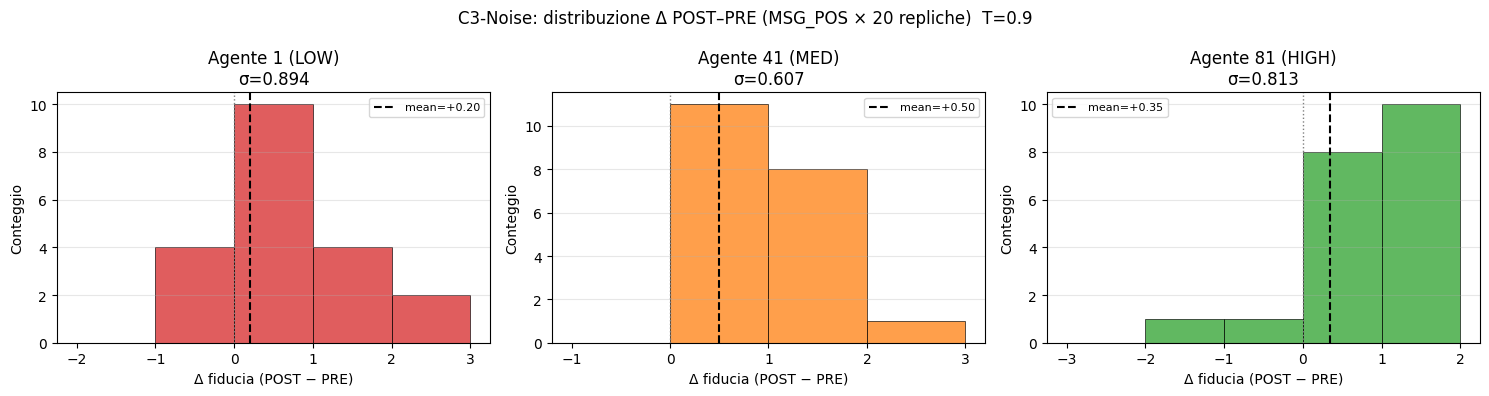

Plot salvato in /content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2/c3_noise_t09_20260629_171436


In [ ]:
## ============================================================
## C3-NOISE — Sottoesperimento di caratterizzazione del noise floor
## ============================================================
##
## Obiettivo: stimare sigma_noise con n repliche identiche (MSG_POS)
## su pochi agenti rappresentativi (1 per fascia LOW/MED/HIGH),
## a temperature diverse.
##
## Design:
##   - 3 agenti fissi (id scelti sotto, uno per gruppo)
##   - n_reps repliche identiche della condizione POS per ciascuno
##   - temperatura impostata tramite CURRENT_TEMPERATURE prima di lanciare
##
##
## Esegui questo blocco una volta per ogni temperatura che vuoi testare.
## I risultati si salvano in una sottocartella dedicata su Drive.
## ============================================================


# ── Parametri ────────────────────────────────────────────────────────────────

# Scegli un agente rappresentativo per fascia.
# Suggerimento: usa il primo di ogni gruppo, oppure uno "neutro" (PRE ≈ media).
C3_AGENTS = {
    "LOW":  GRUPPI["LOW"][0],   # agente 1  (sfiduciato critico)
    "MED":  GRUPPI["MED"][0],   # agente 41 (pragmatico riflessivo)
    "HIGH": GRUPPI["HIGH"][0],  # agente 81 (proattivo collaborativo)
}

N_REPS = 20   # numero di repliche identiche per agente

print(f"C3-Noise: {len(C3_AGENTS)} agenti × {N_REPS} repliche a T={CURRENT_TEMPERATURE}")
print(f"Agenti selezionati: {C3_AGENTS}")
print(f"Chiamate stimate: {len(C3_AGENTS) * N_REPS * 13}  ")


# ── Output directory per questo esperimento ──────────────────────────────────

_temp_tag = f"t{CURRENT_TEMPERATURE}".replace(".", "")
C3_DIR = BASE_DIR / f"c3_noise_{_temp_tag}_{_dtclass.now().strftime('%Y%m%d_%H%M%S')}"
C3_DIR.mkdir(parents=True, exist_ok=True)
print("Output in:", C3_DIR)


# ── Esecuzione ───────────────────────────────────────────────────────────────

import asyncio

C3_ROWS = []   # (agent_id, gruppo, rep, item, phase, value)

async def run_c3_rep(record, rep_idx):
    """Esegue una singola replica della condizione POS per un agente."""
    agent_id = record["id"]
    gruppo   = record["gruppo"]
    profile  = build_profile(record)
    narrative = [{"role": "system", "content": build_system_prompt(profile)}]

    # PRE
    pre = await ask_battery_minimal(narrative, "PRE", agent_id, gruppo,
                                    condition=f"C3_REP{rep_idx:02d}")
    # Iniezione stimolo POS + 3 reazioni
    narrative.append({"role": "user",
                       "content": f"[Comunicazione del Comune di Montelago]\n{MSG_POS}"})
    reazione = await call_llm(narrative, max_tokens=400, call_type="reaction",
                               agent_id=agent_id, gruppo=gruppo,
                               condition=f"C3_REP{rep_idx:02d}")
    narrative.append({"role": "assistant", "content": reazione})
    for marker in TIME_MARKERS[1:]:
        narrative.append({"role": "user", "content": marker})
        reazione = await call_llm(narrative, max_tokens=400, call_type="reaction",
                                   agent_id=agent_id, gruppo=gruppo,
                                   condition=f"C3_REP{rep_idx:02d}")
        narrative.append({"role": "assistant", "content": reazione})

    # POST
    post = await ask_battery_minimal(narrative, "POST", agent_id, gruppo,
                                     condition=f"C3_REP{rep_idx:02d}")

    # Registra delta per ogni item numerico
    for item in ["fiducia_istituzione", "credibilita", "adeguatezza_info"]:
        pre_val  = pre.get(item)
        post_val = post.get(item)
        delta    = (post_val - pre_val) if (pre_val is not None and post_val is not None) else None
        C3_ROWS.append({
            "agent_id": agent_id, "gruppo": gruppo,
            "rep": rep_idx, "item": item,
            "pre": pre_val, "post": post_val, "delta": delta,
            "temperature": CURRENT_TEMPERATURE,
        })

    print(f"  rep {rep_idx:02d} | agente {agent_id} ({gruppo}) | "
          f"fiducia PRE={pre.get('fiducia_istituzione')} "
          f"POST={post.get('fiducia_istituzione')} "
          f"Δ={post.get('fiducia_istituzione', 0) - pre.get('fiducia_istituzione', 0)}")


async def run_c3_experiment():
    for gruppo, aid in C3_AGENTS.items():
        record = META[aid]
        print(f"\n=== Agente {aid} ({gruppo} — {record['persona']}) ===")
        for rep in range(N_REPS):
            await run_c3_rep(record, rep)
        # Checkpoint intermedio per gruppo
        pd.DataFrame(C3_ROWS).to_csv(C3_DIR / f"c3_noise_{gruppo}.csv", index=False)
        print(f"  → checkpoint salvato per {gruppo}")

await run_c3_experiment()
print("\nEsperimento C3-Noise completato.")


# ── Analisi ─────────────────────────────────────────────────────────────────

c3_df = pd.DataFrame(C3_ROWS)
c3_df.to_csv(C3_DIR / "c3_noise_full.csv", index=False)

print(f"\n{'='*60}")
print(f"C3-NOISE — RISULTATI  (T={CURRENT_TEMPERATURE})")
print(f"{'='*60}")
print(f"\nN repliche per agente: {N_REPS}")

for item in ["fiducia_istituzione", "credibilita", "adeguatezza_info"]:
    print(f"\n── Item: {item} ──")
    print(f"  {'gruppo':>6} | {'mean_delta':>11} {'sd_delta':>10} {'min':>6} {'max':>6}")
    print(f"  {'-'*46}")
    for gruppo in ["LOW", "MED", "HIGH"]:
        sub = c3_df[(c3_df["gruppo"] == gruppo) & (c3_df["item"] == item)]["delta"].dropna()
        print(f"  {gruppo:>6} | {sub.mean():>+11.3f} {sub.std():>10.3f} "
              f"{sub.min():>6.1f} {sub.max():>6.1f}")

# Stima noise floor: sd dei delta pooled su tutti e 3 gli agenti (item fiducia)
fiducia_deltas = c3_df[c3_df["item"] == "fiducia_istituzione"]["delta"].dropna()
print(f"\n── Noise floor pooled (fiducia_istituzione) ──")
print(f"  N osservazioni: {len(fiducia_deltas)}")
print(f"  mean delta:     {fiducia_deltas.mean():+.3f}")
print(f"  sd (noise):     {fiducia_deltas.std():.3f}")
print(f"  min / max:      {fiducia_deltas.min():.1f} / {fiducia_deltas.max():.1f}")

# Distribuzione dei delta (quante volte lo stesso valore viene dato)
print(f"\n── Distribuzione dei delta (fiducia, tutti gli agenti) ──")
print(fiducia_deltas.value_counts().sort_index().to_string())

# Confronto sd inter-agente (variabilità idiosincratica del noise)
print(f"\n── sd per agente (noise idiosincratico) ──")
for aid in C3_AGENTS.values():
    sub = c3_df[(c3_df["agent_id"] == aid) & (c3_df["item"] == "fiducia_istituzione")]["delta"].dropna()
    g = c3_df[c3_df["agent_id"] == aid]["gruppo"].iloc[0]
    print(f"  agente {aid:3d} ({g:4s}): mean={sub.mean():+.3f}  sd={sub.std():.3f}  "
          f"range=[{sub.min():.0f}, {sub.max():.0f}]")

print(f"\n{'='*60}")
print(f"File salvati in: {C3_DIR}")
print(f"{'='*60}")


# ── Plot distribuzione delta ─────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(f"C3-Noise: distribuzione Δ POST–PRE (MSG_POS × {N_REPS} repliche)  "
             f"T={CURRENT_TEMPERATURE}", fontsize=12)

colors = {"LOW": "#d62728", "MED": "#ff7f0e", "HIGH": "#2ca02c"}

for ax, (gruppo, aid) in zip(axes, C3_AGENTS.items()):
    sub = c3_df[(c3_df["agent_id"] == aid) & (c3_df["item"] == "fiducia_istituzione")]["delta"].dropna()
    ax.hist(sub, bins=range(int(sub.min())-1, int(sub.max())+2),
            color=colors[gruppo], alpha=0.75, edgecolor="black", linewidth=0.6)
    ax.axvline(sub.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean={sub.mean():+.2f}")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"Agente {aid} ({gruppo})\nσ={sub.std():.3f}")
    ax.set_xlabel("Δ fiducia (POST − PRE)")
    ax.set_ylabel("Conteggio")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(C3_DIR / f"c3_noise_distribution_t{_temp_tag}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot salvato in {C3_DIR}")

Run C3-noise trovati: 1
  c3_noise_t02_20260629_145959

Temperature disponibili: [np.float64(0.2)]
Repliche per run: {0.2: 20}
Agenti per run:   {0.2: 3}

NOISE FLOOR — sd(delta) per temperatura, item=fiducia_istituzione
     T |  n_obs |  mean_delta |  sd_noise |   min   max |   p (mean=0)
-----------------------------------------------------------------
   0.2 |     60 |      +0.233 |     0.810 |  -1.0   2.0 |       0.0295

── credibilita ──
     T |  mean_delta |  sd_noise
--------------------------------
   0.2 |      +0.250 |     0.876

── adeguatezza_info ──
     T |  mean_delta |  sd_noise
--------------------------------
   0.2 |      +0.833 |     0.994

NOISE IDIOSINCRATICO — sd(delta) per agente × temperatura
(item=fiducia_istituzione)
     T | ag1(LOW ) | ag41(MED ) | ag81(HIGH)
--------------------------------------------
   0.2 |         0.967 |         0.587 |         0.852

TEST DI NORMALITÀ — Shapiro-Wilk su delta per temperatura
(item=fiducia_istituzione, pooled su tut

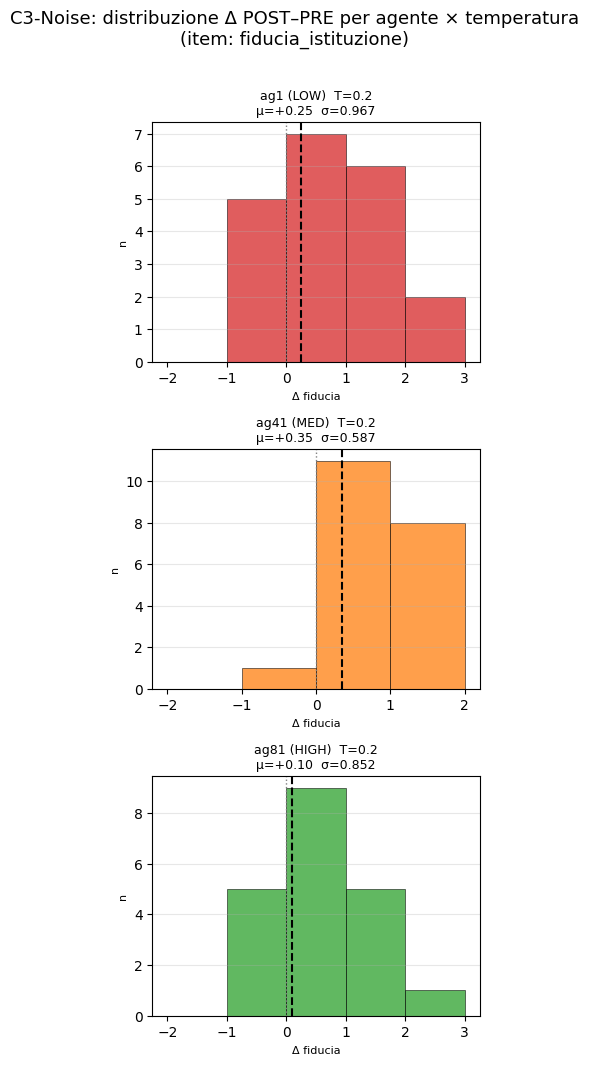


Plot salvato in: /content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2/c3_noise_comparison.png


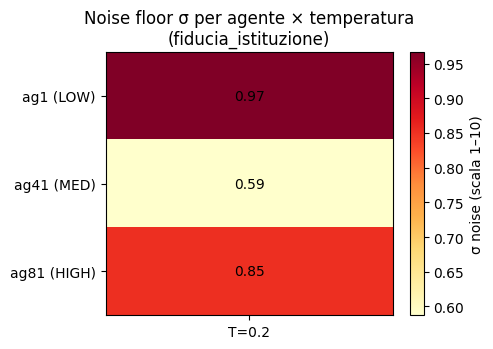

Heatmap salvata in: /content/drive/MyDrive/Colab Notebooks/SyntheticPopulation/SIVE/results_minimal2/c3_noise_heatmap.png

SINTESI C3-NOISE

     T |  σ pooled |  mean bias |  ROPE C3b |  SNR stima*
-------------------------------------------------------
   0.2 |     0.810 |     +0.233 |      PASS |        2.23

* SNR = (delta_POS - delta_NEG)_SIVE / sigma_noise_C3
  Valori SIVE usati: {0.2: 0.158, 0.5: 0.283, 0.7: 0.292}


In [ ]:
## ============================================================
## C3-NOISE — Analisi comparativa across temperature
## ============================================================
##
## Carica tutti i run c3_noise_tXX_* trovati in BASE_DIR,
## li unisce e produce tabelle + plot comparativi.
## ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from scipy import stats

# ── Caricamento automatico di tutti i run C3-noise trovati ──────────────────

c3_runs = sorted(BASE_DIR.glob("c3_noise_t*"))
print(f"Run C3-noise trovati: {len(c3_runs)}")
for r in c3_runs:
    print(f"  {r.name}")

dfs = []
for run_dir in c3_runs:
    f = run_dir / "c3_noise_full.csv"
    if f.exists():
        df = pd.read_csv(f)
        dfs.append(df)
    else:
        print(f"  ⚠️  {run_dir.name}: c3_noise_full.csv non trovato, skip")

if not dfs:
    raise RuntimeError("Nessun file trovato. Verifica BASE_DIR e i nomi delle cartelle.")

ALL = pd.concat(dfs, ignore_index=True)
TEMPS = sorted(ALL["temperature"].unique())
GRUPPI_ORDER = ["LOW", "MED", "HIGH"]
ITEMS = ["fiducia_istituzione", "credibilita", "adeguatezza_info"]

print(f"\nTemperature disponibili: {TEMPS}")
print(f"Repliche per run: {ALL.groupby('temperature')['rep'].nunique().to_dict()}")
print(f"Agenti per run:   {ALL.groupby('temperature')['agent_id'].nunique().to_dict()}")


# ── 1. Tabella riepilogativa: noise floor per temperatura ───────────────────

print(f"\n{'='*65}")
print("NOISE FLOOR — sd(delta) per temperatura, item=fiducia_istituzione")
print(f"{'='*65}")
print(f"{'T':>6} | {'n_obs':>6} | {'mean_delta':>11} | {'sd_noise':>9} | "
      f"{'min':>5} {'max':>5} | {'p (mean=0)':>12}")
print(f"{'-'*65}")

for t in TEMPS:
    sub = ALL[(ALL["temperature"] == t) & (ALL["item"] == "fiducia_istituzione")]["delta"].dropna()
    tstat, pval = stats.ttest_1samp(sub, 0)
    print(f"{t:>6.1f} | {len(sub):>6} | {sub.mean():>+11.3f} | {sub.std():>9.3f} | "
          f"{sub.min():>5.1f} {sub.max():>5.1f} | {pval:>12.4f}")

# Stesso per gli altri item
for item in ["credibilita", "adeguatezza_info"]:
    print(f"\n── {item} ──")
    print(f"{'T':>6} | {'mean_delta':>11} | {'sd_noise':>9}")
    print(f"{'-'*32}")
    for t in TEMPS:
        sub = ALL[(ALL["temperature"] == t) & (ALL["item"] == item)]["delta"].dropna()
        print(f"{t:>6.1f} | {sub.mean():>+11.3f} | {sub.std():>9.3f}")


# ── 2. Noise floor per agente × temperatura (idiosincratico) ────────────────

print(f"\n{'='*65}")
print("NOISE IDIOSINCRATICO — sd(delta) per agente × temperatura")
print(f"(item=fiducia_istituzione)")
print(f"{'='*65}")

agents_in_exp = sorted(ALL["agent_id"].unique())
header = f"{'T':>6} | " + " | ".join(f"ag{a}({ALL[ALL['agent_id']==a]['gruppo'].iloc[0]:4s})" for a in agents_in_exp)
print(header)
print("-" * len(header))

for t in TEMPS:
    row = f"{t:>6.1f} | "
    parts = []
    for aid in agents_in_exp:
        sub = ALL[(ALL["temperature"] == t) & (ALL["agent_id"] == aid) &
                  (ALL["item"] == "fiducia_istituzione")]["delta"].dropna()
        if len(sub) > 0:
            parts.append(f"{sub.std():>13.3f}")
        else:
            parts.append(f"{'n/a':>13}")
    print(row + " | ".join(parts))


# ── 3. Distribuzione dei delta: è gaussiana? ────────────────────────────────

print(f"\n{'='*65}")
print("TEST DI NORMALITÀ — Shapiro-Wilk su delta per temperatura")
print(f"(item=fiducia_istituzione, pooled su tutti gli agenti)")
print(f"{'='*65}")
print(f"{'T':>6} | {'W':>8} | {'p':>8} | {'gaussiana?':>12}")
print(f"{'-'*42}")

for t in TEMPS:
    sub = ALL[(ALL["temperature"] == t) & (ALL["item"] == "fiducia_istituzione")]["delta"].dropna()
    if len(sub) >= 3:
        W, p = stats.shapiro(sub)
        gauss = "✅ sì" if p > 0.05 else "❌ no"
        print(f"{t:>6.1f} | {W:>8.4f} | {p:>8.4f} | {gauss:>12}")


# ── 4. ROPE test: |mean_diff| < 0.5 (criterio C3b) ──────────────────────────

print(f"\n{'='*65}")
print("C3b ROPE TEST — |mean(delta)| < 0.5 scale points")
print(f"(indipendente dal p-value del t-test)")
print(f"{'='*65}")
print(f"{'T':>6} | {'mean_delta':>11} | {'|mean|<0.5?':>12} | {'C3b':>6}")
print(f"{'-'*45}")

for t in TEMPS:
    sub = ALL[(ALL["temperature"] == t) & (ALL["item"] == "fiducia_istituzione")]["delta"].dropna()
    m = sub.mean()
    ok = abs(m) < 0.5
    print(f"{t:>6.1f} | {m:>+11.3f} | {'✅ PASS' if ok else '❌ FAIL':>12} | "
          f"{'PASS' if ok else 'FAIL':>6}")


# ── 5. Plot comparativo ──────────────────────────────────────────────────────

n_temps = len(TEMPS)
n_agents = len(agents_in_exp)
colors_g = {"LOW": "#d62728", "MED": "#ff7f0e", "HIGH": "#2ca02c"}

fig, axes = plt.subplots(n_agents, n_temps,
                          figsize=(4 * n_temps, 3.5 * n_agents),
                          squeeze=False)
fig.suptitle("C3-Noise: distribuzione Δ POST–PRE per agente × temperatura\n"
             "(item: fiducia_istituzione)", fontsize=13, y=1.01)

for row, aid in enumerate(agents_in_exp):
    gruppo = ALL[ALL["agent_id"] == aid]["gruppo"].iloc[0]
    for col, t in enumerate(TEMPS):
        ax = axes[row][col]
        sub = ALL[(ALL["temperature"] == t) & (ALL["agent_id"] == aid) &
                  (ALL["item"] == "fiducia_istituzione")]["delta"].dropna()

        if len(sub) == 0:
            ax.text(0.5, 0.5, "n/a", ha="center", va="center",
                    transform=ax.transAxes)
            continue

        bins = range(int(sub.min()) - 1, int(sub.max()) + 2)
        ax.hist(sub, bins=bins, color=colors_g[gruppo], alpha=0.75,
                edgecolor="black", linewidth=0.5)
        ax.axvline(sub.mean(), color="black", linestyle="--", linewidth=1.5)
        ax.axvline(0, color="gray", linestyle=":", linewidth=1)
        ax.set_title(f"ag{aid} ({gruppo})  T={t}\n"
                     f"μ={sub.mean():+.2f}  σ={sub.std():.3f}", fontsize=9)
        ax.set_xlabel("Δ fiducia", fontsize=8)
        ax.set_ylabel("n", fontsize=8)
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()

out_plot = BASE_DIR / "c3_noise_comparison.png"
plt.savefig(out_plot, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nPlot salvato in: {out_plot}")


# ── 6. Heatmap: sd noise × agente × temperatura ─────────────────────────────

import matplotlib.colors as mcolors

fig2, ax = plt.subplots(figsize=(max(5, n_temps * 1.8), max(3, n_agents * 1.2)))

heat = np.zeros((n_agents, n_temps))
for i, aid in enumerate(agents_in_exp):
    for j, t in enumerate(TEMPS):
        sub = ALL[(ALL["temperature"] == t) & (ALL["agent_id"] == aid) &
                  (ALL["item"] == "fiducia_istituzione")]["delta"].dropna()
        heat[i, j] = sub.std() if len(sub) > 1 else np.nan

im = ax.imshow(heat, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="σ noise (scala 1–10)")
ax.set_xticks(range(n_temps))
ax.set_xticklabels([f"T={t}" for t in TEMPS])
ax.set_yticks(range(n_agents))
ax.set_yticklabels([f"ag{a} ({ALL[ALL['agent_id']==a]['gruppo'].iloc[0]})"
                    for a in agents_in_exp])
for i in range(n_agents):
    for j in range(n_temps):
        ax.text(j, i, f"{heat[i,j]:.2f}", ha="center", va="center",
                fontsize=10, color="black" if heat[i,j] < 2 else "white")
ax.set_title("Noise floor σ per agente × temperatura\n(fiducia_istituzione)")

plt.tight_layout()
out_heat = BASE_DIR / "c3_noise_heatmap.png"
plt.savefig(out_heat, dpi=150, bbox_inches="tight")
plt.show()
print(f"Heatmap salvata in: {out_heat}")


# ── 7. Sintesi finale ────────────────────────────────────────────────────────

print(f"\n{'='*65}")
print("SINTESI C3-NOISE")
print(f"{'='*65}")
print(f"\n{'T':>6} | {'σ pooled':>9} | {'mean bias':>10} | {'ROPE C3b':>9} | {'SNR stima*':>11}")
print(f"{'-'*55}")

# SNR stimato come (delta_POS_medio del run principale) / sigma_noise
# Usa i valori dal report principale se disponibili, altrimenti solo sigma
for t in TEMPS:
    sub = ALL[(ALL["temperature"] == t) & (ALL["item"] == "fiducia_istituzione")]["delta"].dropna()
    sigma = sub.std()
    mean  = sub.mean()
    rope  = "PASS" if abs(mean) < 0.5 else "FAIL"
    # SNR approssimativo: delta_POS dal run SIVE principale diviso sigma qui stimato
    # (inserisci i valori dal report se li hai)
    sive_delta_pos = {0.2: 0.158, 0.5: 0.283, 0.7: 0.292}  # dal report SIVE
    sive_delta_neg = {0.2: -1.650, 0.5: -1.683, 0.7: -1.658}
    if t in sive_delta_pos:
        snr = (sive_delta_pos[t] - sive_delta_neg[t]) / sigma
        snr_str = f"{snr:>11.2f}"
    else:
        snr_str = f"{'n/a':>11}"
    print(f"{t:>6.1f} | {sigma:>9.3f} | {mean:>+10.3f} | {rope:>9} | {snr_str}")

print(f"\n* SNR = (delta_POS - delta_NEG)_SIVE / sigma_noise_C3")
print(f"  Valori SIVE usati: {sive_delta_pos}")